In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 8
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2xlb25tYXJ0aW5fYmloL3Byb2plY3RzL1RWQi1PL3R2Yi1vbnRvbG9neS1vcHRpbS13b3Jrc2hvcC9ub3RlYm9va3M='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap_external.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/zipimport.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/codecs.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/aliases.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/__init__.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/utf_8.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks

In [2]:
#| output: false
import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "../img/section-1"
DPI = 200
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, **kw):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=DPI, bbox_inches="tight", **kw)
    print(f"saved → {path}")

In [3]:
#| output: false
import networkx as nx
from matplotlib.lines import Line2D

cividis = plt.get_cmap("cividis")
c_node     = cividis(0.65)
c_affected = cividis(0.88)
c_lesion   = "#c62828"
c_edge     = "#9e9e9e"
c_edge_cut = "#c62828"

# Shared node positions — identical between the two panels by design.
positions = {
    0: ( 0.00,  0.00),   # the lesioned node (same in both panels)
    1: ( 1.20,  0.40),
    2: ( 1.30, -0.55),
    3: (-1.10,  0.55),
    4: (-1.30, -0.40),
    5: ( 0.50,  1.20),
    6: (-0.55, -1.20),
    7: ( 2.00,  1.10),
    8: (-2.00, -0.95),
    9: ( 1.00, -1.50),
}

def make_hub():
    """Patient A: lesion node 0 sits at a hub (degree 6)."""
    G = nx.Graph()
    G.add_nodes_from(range(10))
    G.add_edges_from([
        (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6),
        (1, 7), (2, 9), (3, 8), (4, 8), (5, 7), (6, 9),
        (1, 2),
    ])
    return G

def make_periphery():
    """Patient B: lesion node 0 sits at the periphery (degree 1)."""
    G = nx.Graph()
    G.add_nodes_from(range(10))
    G.add_edges_from([
        (0, 1),
        (1, 2), (1, 3), (2, 3), (2, 5), (3, 4),
        (4, 5), (4, 6), (5, 7), (6, 8), (7, 8),
        (7, 9), (8, 9),
    ])
    return G

def draw_panel(ax, G, title, lesion=0):
    affected = set(G.neighbors(lesion))

    for (u, v) in G.edges():
        cut = (u == lesion or v == lesion)
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        ax.plot(
            x, y,
            color=c_edge_cut if cut else c_edge,
            linestyle="--" if cut else "-",
            linewidth=2.0 if cut else 1.6,
            alpha=0.85 if cut else 0.7,
            zorder=1,
        )

    for n, (x, y) in positions.items():
        if n == lesion:
            continue
        in_deficit = n in affected
        ax.scatter(
            [x], [y],
            s=620,
            color=c_affected if in_deficit else c_node,
            edgecolors=c_lesion if in_deficit else "black",
            linewidths=2.0 if in_deficit else 1.2,
            zorder=3,
        )

    lx, ly = positions[lesion]
    ax.scatter([lx], [ly], s=720, marker="X",
               color=c_lesion, edgecolors="black", linewidths=1.6, zorder=4)

    deg = G.degree(lesion)
    ax.set_title(f"{title}\nlesion degree = {deg}", fontsize=13)
    ax.set_xlim(-2.6, 2.6)
    ax.set_ylim(-2.0, 1.7)
    ax.set_aspect("equal")
    ax.axis("off")

saved → ../img/section-1/lesion_network.png


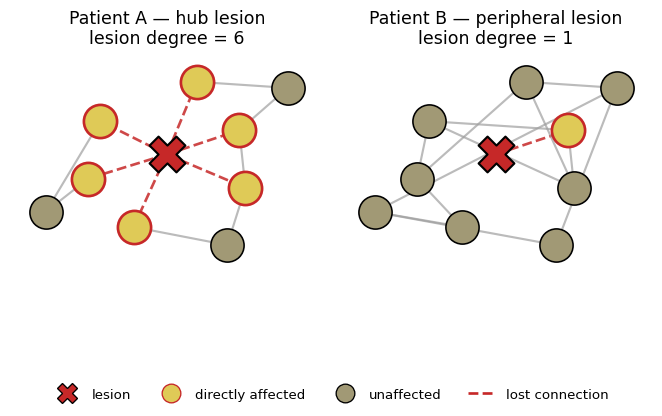

In [4]:
#| label: fig-lesion-network
#| fig-cap: 'Same lesion (red ✕), same physical location, same surrounding nodes — but the *connectivity* differs. Left: a hub lesion knocks out six direct connections; the deficit territory (red-rimmed) covers most of the network. Right: the same lesion at a peripheral node touches one neighbour and the rest of the network is untouched.'

fig, axes = plt.subplots(1, 2, figsize=(7.0, 5.0))
draw_panel(axes[0], make_hub(),       "Patient A — hub lesion")
draw_panel(axes[1], make_periphery(), "Patient B — peripheral lesion")

handles = [
    Line2D([0], [0], marker="X", color="w", markerfacecolor=c_lesion,
           markeredgecolor="black", markersize=15, label="lesion"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c_affected,
           markeredgecolor=c_lesion, markersize=14, label="directly affected"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c_node,
           markeredgecolor="black", markersize=14, label="unaffected"),
    Line2D([0], [0], color=c_edge_cut, linestyle="--", linewidth=2.0,
           label="lost connection"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
savefig("lesion_network.png")
plt.show()

In [5]:
#| output: false
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(7)

# --- module assignment ----------------------------------------------------
modules = [
    ("module 1", [0, 1, 2]),
    ("module 2", [3, 4, 5]),
    ("module 3", [6, 7]),
]
n_regions = sum(len(idx) for _, idx in modules)
region_to_module = {r: m for m, (_, idx) in enumerate(modules) for r in idx}

cividis = plt.get_cmap("cividis")
module_colors = [cividis(0.20), cividis(0.55), cividis(0.85)]

# --- synthetic resting-state-like signals ---------------------------------
fs = 10.0                   # samples per second
T = 60.0                    # seconds
n_t = int(fs * T)
t = np.arange(n_t) / fs

def slow_latent(seed):
    """Smooth low-frequency latent: filtered noise."""
    raw = rng.standard_normal(n_t)
    return gaussian_filter1d(raw, sigma=fs * 1.5)   # ~0.1 Hz

latents = np.stack([slow_latent(m) for m in range(len(modules))])

signals = np.zeros((n_regions, n_t))
for r in range(n_regions):
    m = region_to_module[r]
    shared = latents[m]
    idiosyncratic = gaussian_filter1d(rng.standard_normal(n_t), sigma=fs * 0.4)
    s = 1.0 * shared + 0.20 * idiosyncratic
    signals[r] = (s - s.mean()) / s.std()

# --- functional connectivity ---------------------------------------------
fc = np.corrcoef(signals)

saved → ../img/section-1/rest_structured.png


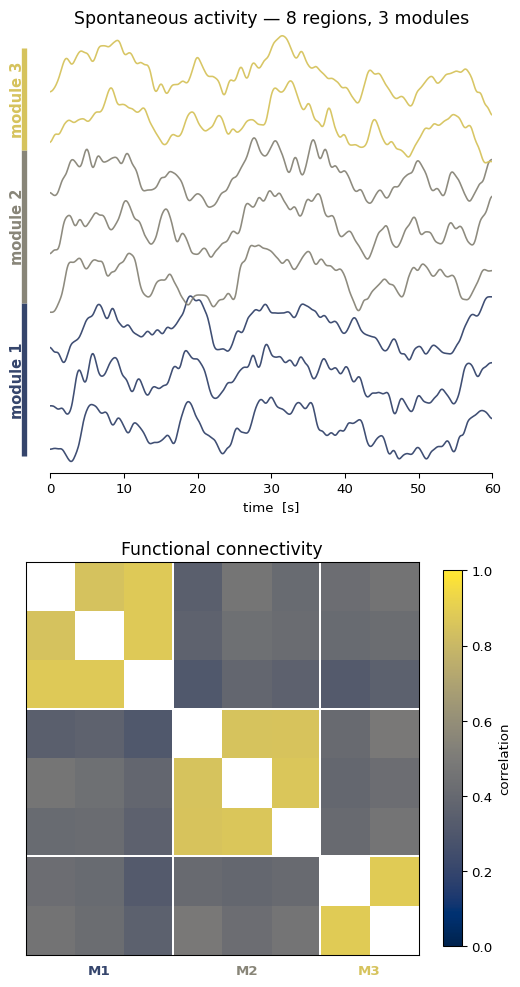

In [6]:
#| label: fig-rest-structured
#| fig-cap: 'Synthetic resting activity for 8 regions in 3 modules. Left: stacked traces over 60 s — within-module signals wiggle together (shared slow latent), across modules they are decoupled. Right: the resulting functional-connectivity matrix shows three blocks along the diagonal. Same idea as empirical resting-state networks: spontaneous activity already carries structure.'

fig, (ax_t, ax_fc) = plt.subplots(
    2, 1, figsize=(5.5, 10.5), gridspec_kw={"height_ratios": [1.0, 1.0]}
)
ax_t.set_box_aspect(1)
ax_fc.set_box_aspect(1)

# --- traces panel ---------------------------------------------------------
offset_step = 3.0
for r in range(n_regions):
    m = region_to_module[r]
    ax_t.plot(t, signals[r] + r * offset_step,
              color=module_colors[m], lw=1.2, alpha=0.95)

# module brackets on the left
for m_idx, (label, regs) in enumerate(modules):
    y_lo = regs[0] * offset_step - 1.5
    y_hi = regs[-1] * offset_step + 1.5
    ax_t.plot([-3.5, -3.5], [y_lo, y_hi],
              color=module_colors[m_idx], lw=4, solid_capstyle="butt",
              clip_on=False)
    ax_t.text(-4.5, (y_lo + y_hi) / 2, label,
              rotation=90, ha="center", va="center",
              color=module_colors[m_idx], fontsize=11, fontweight="bold")

ax_t.set_xlim(0, T)
ax_t.set_ylim(-2.5, n_regions * offset_step - 0.5)
ax_t.set_xlabel("time  [s]")
ax_t.set_yticks([])
ax_t.set_title("Spontaneous activity — 8 regions, 3 modules", fontsize=13)
for spine in ("top", "right", "left"):
    ax_t.spines[spine].set_visible(False)

# --- FC panel -------------------------------------------------------------
fc_show = fc.copy()
np.fill_diagonal(fc_show, np.nan)
im = ax_fc.imshow(fc_show, cmap="cividis", vmin=0, vmax=1)
ax_fc.set_title("Functional connectivity", fontsize=13)
ax_fc.set_xticks([]); ax_fc.set_yticks([])

# module dividers
boundaries = np.cumsum([len(idx) for _, idx in modules])[:-1] - 0.5
for b in boundaries:
    ax_fc.axhline(b, color="white", lw=1.5)
    ax_fc.axvline(b, color="white", lw=1.5)

# module labels along the FC axes
starts = [0] + list(np.cumsum([len(idx) for _, idx in modules])[:-1])
ends   = list(np.cumsum([len(idx) for _, idx in modules]))
for m_idx, (start, end) in enumerate(zip(starts, ends)):
    mid = (start + end - 1) / 2
    ax_fc.text(mid, n_regions - 0.3, f"M{m_idx + 1}",
               ha="center", va="top",
               color=module_colors[m_idx], fontsize=10, fontweight="bold",
               transform=ax_fc.transData)

plt.colorbar(im, ax=ax_fc, shrink=0.85, label="correlation")

plt.tight_layout()
savefig("rest_structured.png")
plt.show()